In [2]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from kagglehub import KaggleDatasetAdapter
from sklearn.metrics import recall_score
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.metrics import precision_score, f1_score, confusion_matrix
from imblearn.ensemble import BalancedRandomForestClassifier

file_path_diabetes = "diabetes_prediction_dataset.csv"

df_diabetes = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS,"iammustafatz/diabetes-prediction-dataset",file_path_diabetes)

#Visualizacion de los datos (recoemndacion del autor del Dataset):

df_diabetes.head().style.set_table_styles(
    [{'selector': 'th', 'props':
     [('font-weight', 'bold'), ('background-color', '#f0f0f0')]}] ).set_properties(**{'text-align': 'center'})

# Pasando los datos de la Columna "smoking_history" a Enteros:

df_diabetes["smoking_history"] = df_diabetes["smoking_history"].replace({"current": 1,
      "never": 0,'No Info': 0,'ever': 1,'formerly': 1,'not current': 0, 'former': 0})

df_diabetes['smoking_history'] = df_diabetes['smoking_history'].astype(int)

#Cambiando la edad a Enteros:

df_diabetes['age'] = df_diabetes['age'].astype(int)

print('Nº Total de filas y columnas:\n',df_diabetes.shape)
print(df_diabetes.head())
print(df_diabetes.info())
print(df_diabetes.describe())

/tmp/ipykernel_278/4013838846.py:14: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_diabetes = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS,"iammustafatz/diabetes-prediction-dataset",file_path_diabetes)


Using Colab cache for faster access to the 'diabetes-prediction-dataset' dataset.
Nº Total de filas y columnas:
 (100000, 9)
   gender  age  hypertension  heart_disease  smoking_history    bmi  \
0  Female   80             0              1                0  25.19   
1  Female   54             0              0                0  27.32   
2    Male   28             0              0                0  27.32   
3  Female   36             0              0                1  23.45   
4    Male   76             1              1                1  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  


/tmp/ipykernel_278/4013838846.py:24: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_diabetes["smoking_history"] = df_diabetes["smoking_history"].replace({"current": 1,


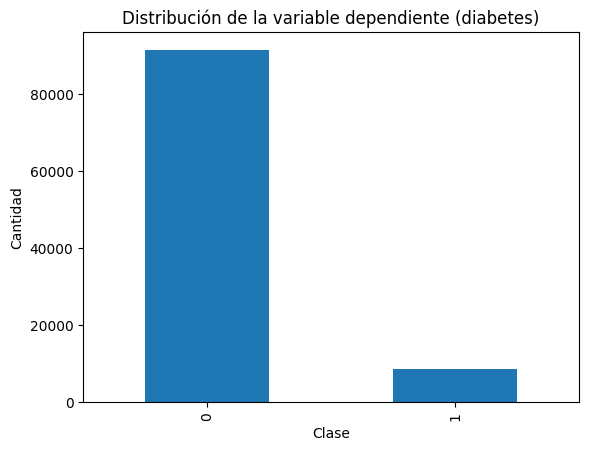

In [ ]:
#Analisadno la cantidad de dianeticos vs no diabeticos (Variable dependiente del ML):

diabetes_colum = "diabetes"
#Extraccion de la columna

counts = df_diabetes[diabetes_colum].value_counts()
#Contar la cantiad de valores

percent = df_diabetes[diabetes_colum].value_counts(normalize=True) * 100 #
# Conatr los valores pero pasarlo a decimales (porcentaje en decimal)

#Creamos un nuevo Dataset que contega Count y percent
balance_table = pd.DataFrame({
    "count": counts,
    "percent": percent.round(2)})

#Muestra Grafica de la dsitribucion de la variable

counts.plot(kind="bar")
plt.title("Distribución de la variable dependiente (diabetes)")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.show()

In [ ]:
#Calcular de ratio entre Diabeticos y No diabeticos:

ratio = counts[0] / counts[1]
ratio = (f"{ratio:.2f}")
print('El dataset presenta un ratio aproximado de',(ratio),': 1 entre casos negativos y positivos de diabeticos')


El dataset presenta un ratio aproximado de 10.76 : 1 entre casos negativos y positivos de diabeticos


In [ ]:
# Variables con la que entrenaremos el modelo:
y = df_diabetes['diabetes']
x = df_diabetes[['age','bmi',
                 'hypertension',
                 'heart_disease',
                 'smoking_history',
                 'blood_glucose_level',
                 'HbA1c_level']]

In [ ]:
#CONSTRUCCION DEL MODELO:

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.15, random_state=42)
#Dividimos los datos que seran para entrenar
#y cuales son para evaluar


#Recordar que hay un claro desbalance entre no dibeticos y diabeticos

#ENTRENAR EL MODELO:

#Se hara uso de BalancedRandomForestClassifier, debido a que la variable dependiente (Diabetes) al estar tan desbalanceada puede generar confucion al modelo:

#Se hizo pruebas con otros modelos, se cambio el threshold de esos modelos, se cambio el SMOTE y se hizo uso de Class_weight = "balanced". Pero el que si ayudo con que
# el recall fuese superior al 80% (que en el area de la salud es un porcentaje permisible) fue BalancedRandomForestClassifier.

random_forest_model = BalancedRandomForestClassifier(random_state=42,n_estimators=300)
random_forest_model.fit(x_train, y_train)

#En esta parte se determina el threshold (Umbral de aceptacion del modelo)
#predict_proba -- es util al momento de ajustar el umbral de aceptacion o entender la confianza del modelo en sus predicciones
# De X_text, tomamos la seguanda columna (Positivo pa diabetes) y le aplicamos predict_proba
y_pred_rf = random_forest_model.predict_proba(x_test)[:, 1]

#Un array que contiene las probabilidades de que cada muestra pertenezca a la clase positiva

#Nuevo Threshold (Limite)
new_threshold = 0.5
# El el nuevo umbral de aceptacion

y_pred_rf_new_threshold = (y_pred_rf >= new_threshold).astype(int)
#Esta parte es fundamental para que funcione el cambio del umbral:
# La creacion de un nuevo array de valores booleanos (True o False). En este caso el


recall_rf = recall_score(y_test, y_pred_rf_new_threshold)
print(f"Recall Score con Random Forest {recall_rf}") #Con RandomForest es superior el 80%

Recall Score con Random Forest 0.881619937694704


Precision Score con Random Forest: 0.5173674588665448
F1-Score con Random Forest: 0.652073732718894
Matriz de Confusión con Random Forest:
[[12660  1056]
 [  152  1132]]


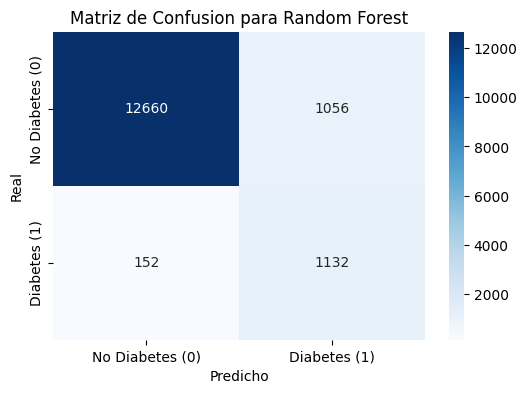

In [ ]:
# Calcular precisión del Modelo:
#Lo uso como guia para saber que tanto afecta el aumento del recall
precision_rf = precision_score(y_test, y_pred_rf_new_threshold)
print(f"Precision Score con Random Forest: {precision_rf}")

# Calcular F1-score:
f1_rf = f1_score(y_test, y_pred_rf_new_threshold)
print(f"F1-Score con Random Forest: {f1_rf}")

# Matriz de Confusion:
cm_rf = confusion_matrix(y_test, y_pred_rf_new_threshold)
print("Matriz de Confusión con Random Forest:")
print(cm_rf)

# Visualizar la matriz de confusion:
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes (0)', 'Diabetes (1)'],
            yticklabels=['No Diabetes (0)', 'Diabetes (1)'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusion para Random Forest')
plt.show()

In [ ]:
# Simulacion de precicio de nueva persona:
#Los datos son muy claros para que vea a la persona como TP diabetes tipo 2
nueva_persona_data = pd.DataFrame({
    'age': [22],
    'bmi': [20.3],
    'hypertension': [0],
    'heart_disease': [0],
    'smoking_history': [0],
    'blood_glucose_level': [0],
    'HbA1c_level': [0]
})

# Realizar la predicción
prediccion = random_forest_model.predict(nueva_persona_data)

# Obtener las probabilidades de predicción
probabilidades = random_forest_model.predict_proba(nueva_persona_data)

print(f"Datos de la nueva persona:\n{nueva_persona_data}")

if prediccion[0] == 1:
    print("\nRiesgo Alto de padecer diabetes tipo II")
else:
    print("\nRiesgo Bajo de padecer diabetes tipo II")

print(f"Probabilidad de NO diabetes: {probabilidades[0][0]:.2f}")
print(f"Probabilidad de diabetes: {probabilidades[0][1]:.2f}")

Datos de la nueva persona:
   age   bmi  hypertension  heart_disease  smoking_history  \
0   22  20.3             0              0                0   

   blood_glucose_level  HbA1c_level  
0                    0            0  

Riesgo Bajo de padecer diabetes tipo II
Probabilidad de NO diabetes: 1.00
Probabilidad de diabetes: 0.00
